In [26]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from forecasting.data.loaders import load_market_data
from forecasting.features.market import (
    add_daily_clf,
    add_is_evening,
    add_nci,
    add_period_enum,
    add_prev_day_purchase_bid,
    add_prev_day_uncleared_vol,
    add_rolling_3d_clf,
    add_uncleared_vol,
    add_weekday_enum,
    get_weather_master,
)

In [27]:
data_indexed = load_market_data("../../data/raw/iex-dam-0201-0421.csv")
data = data_indexed.reset_index()
data.sample()

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
5559,2026-03-30 21:45:00,21:45 - 22:00,16038.1,8345.9,5990.6,10000.0,5990.6


In [28]:
# 1) Load weather master from disk (or fetch from API if missing)
start_date = data['period_start'].min().date().isoformat()
end_date = data['period_start'].max().date().isoformat()
weather_master = get_weather_master(start_date=start_date, end_date=end_date)

# 2) Build features via reusable module functions
features_df = data.copy()
features_df = add_nci(features_df, weather_master=weather_master)
features_df = add_period_enum(features_df)
features_df = add_weekday_enum(features_df)
features_df = add_is_evening(features_df)
features_df = add_daily_clf(features_df)
features_df = add_rolling_3d_clf(features_df)
features_df = add_uncleared_vol(features_df)
features_df = add_prev_day_uncleared_vol(features_df, periods_per_day=96)
features_df = add_prev_day_purchase_bid(features_df, periods_per_day=96)

# Drop rows with lag-based NaNs from shifted features
features_df = features_df.dropna().copy()

print('Fresh Feature Dataframe Created!')
features_df.head()

2026-04-23 17:51:38,359 | INFO | forecasting.features.market | Loading weather master from /Users/dhruvil/Documents/EarthSync/data/weather/weather_master.csv
2026-04-23 17:51:38,442 | WARNING | forecasting.features.market | Added `prev_day_uncleared_vol` with shift=96. Truncate leading rows with NaN before model training.
2026-04-23 17:51:38,447 | WARNING | forecasting.features.market | Added `prev_day_purchase_bid` with shift=96. Truncate leading rows with NaN before model training.


Fresh Feature Dataframe Created!


,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume,date_only,NCI,period_enum,weekday_enum,is_evening,daily_clf,rolling_3d_clf,uncleared_vol,prev_day_uncleared_vol,prev_day_purchase_bid
96,2026-02-02 00:00:00,00:00 - 00:15,12380.9,29543.7,7225.90,2580.46,7225.90,2026-02-02,26.07,1,1,0,0.0,0.0,5155.00,4633.5,11446.6
97,2026-02-02 00:15:00,00:15 - 00:30,13084.5,31204.4,7203.15,2569.69,7203.15,2026-02-02,26.07,2,1,0,0.0,0.0,5881.35,4774.3,12066.8
98,2026-02-02 00:30:00,00:30 - 00:45,13621.6,32825.1,7310.03,2569.58,7310.03,2026-02-02,26.07,3,1,0,0.0,0.0,6311.57,5009.8,12510.9
99,2026-02-02 00:45:00,00:45 - 01:00,13675.3,34558.3,7809.39,2569.01,7809.39,2026-02-02,26.07,4,1,0,0.0,0.0,5865.91,5153.6,12502.6
100,2026-02-02 01:00:00,01:00 - 01:15,13720.1,35119.1,7902.21,2510.89,7902.21,2026-02-02,26.07,5,1,0,0.0,0.0,5817.89,4957.2,12423.8


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Define your features and target
X = features_df[['period_enum', 'weekday_enum', 'is_evening', 
                'rolling_3d_clf', 'prev_day_uncleared_vol', 'prev_day_purchase_bid', 'daily_clf']]
X = features_df[['period_enum', 'weekday_enum', 'rolling_3d_clf']]
y = features_df['purchase_bid']

# Initialize and fit a baseline Random Forest
# We use a shallow depth to avoid overfitting on noise
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_58206/1429674251.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances, palette='magma')


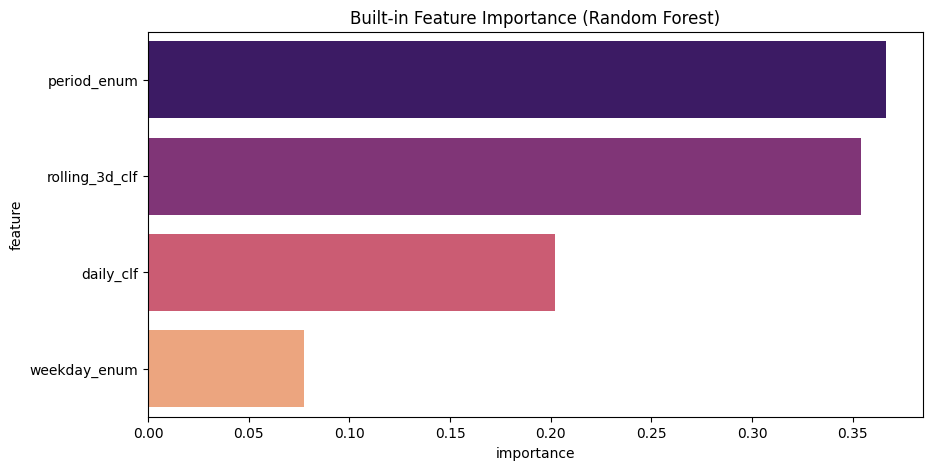

In [24]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importances, palette='magma')
plt.title("Built-in Feature Importance (Random Forest)")
plt.show()

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_58206/54907624.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=perm_importances, palette='viridis')


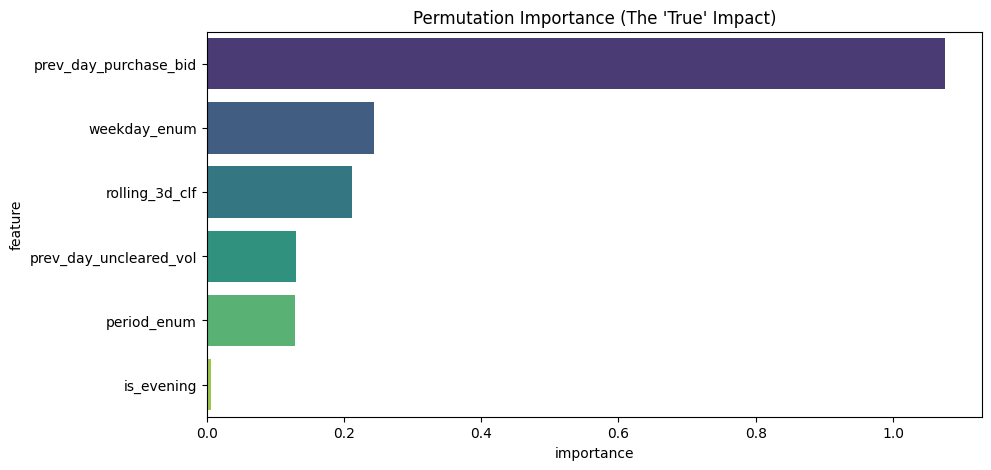

In [20]:
result = permutation_importance(model, X, y, n_repeats=10, random_state=42)

perm_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=perm_importances, palette='viridis')
plt.title("Permutation Importance (The 'True' Impact)")
plt.show()

In [ ]:
# List of required columns
required_columns = [
    'period_start', 'period', 'purchase_bid',
    'rolling_3d_clf', 'period_enum', 'weekday_enum'
]

# Export to CSV
features_df[required_columns].to_csv('iex_dam_features.csv', index=False)

print("File 'iex_market_features_top3.csv' has been saved to your current directory.")

In [25]:
features_df.columns

Index(['period_start', 'period', 'purchase_bid', 'sell_bid', 'mcv', 'mcp',
       'final_scheduled_volume', 'date_only', 'NCI', 'period_enum',
       'weekday_enum', 'is_evening', 'daily_clf', 'rolling_3d_clf',
       'uncleared_vol', 'prev_day_uncleared_vol', 'prev_day_purchase_bid'],
      dtype='object')